In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gdown -q

In [ ]:
import os
import gdown
import shutil
import zipfile
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import cv2
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [ ]:
file_id = '1WXL2-XlQzVr-gVZoMgrXocEkwwNdFHUU'
destination = 'FoodFreshnessSplit.zip'

gdown.download(id=file_id, output=destination, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1WXL2-XlQzVr-gVZoMgrXocEkwwNdFHUU
From (redirected): https://drive.google.com/uc?id=1WXL2-XlQzVr-gVZoMgrXocEkwwNdFHUU&confirm=t&uuid=b7291ca5-dd58-417d-9c73-d7d1fe2e97cf
To: /content/FoodFreshnessSplit.zip
100%|██████████| 2.09G/2.09G [00:36<00:00, 56.6MB/s]


'FoodFreshnessSplit.zip'

In [ ]:
zip_path = "FoodFreshnessSplit.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting to:", extract_path)

Done extracting to: /content


In [ ]:
# os.listdir("/content/FoodFreshnessSplit")

In [ ]:
print(os.listdir('/content/train'))
print(os.listdir('/content/val'))
print(os.listdir('/content/test'))

['RottenApple', 'FreshBanana', 'RottenStrawberry', 'RottenBanana', 'FreshStrawberry', 'FreshApple']
['RottenApple', 'FreshBanana', 'RottenStrawberry', 'RottenBanana', 'FreshStrawberry', 'FreshApple']
['RottenApple', 'FreshBanana', 'RottenStrawberry', 'RottenBanana', 'FreshStrawberry', 'FreshApple']


# Modeling

In [ ]:
from dataclasses import dataclass, field
from pathlib import Path
import gc
import time
import resource

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.models import (
    ResNet18_Weights,
    ResNet50_Weights,
    EfficientNet_B0_Weights,
    MobileNet_V2_Weights,
    MobileNet_V3_Small_Weights,
    DenseNet121_Weights
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

## Config

In [ ]:
@dataclass
class Config:
    dataset_path: str = "/content/"

    # task: str = "binary"
    task: str = "six_class"

    models: list[str] = field(default_factory=lambda: [
        # "resnet18",
        "resnet50",
        "efficientnet_b0",
        "mobilenet_v2",
        "mobilenet_v3_small",
        # "densenet121"
    ])

    img_size: int = 224
    batch_size: int = 32
    epochs: int = 8
    lr: float = 1e-4
    weight_decay: float = 1e-4

    test_size: float = 0.15
    val_size: float = 0.15

    num_workers: int = 2
    seed: int = 42

    pretrained: bool = True

    # True  = train only final classifier layer
    # False = fine-tune the full pretrained model
    freeze_backbone: bool = False

    best_model_dir: str = "best_models"


cfg = Config()

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


seed_everything(cfg.seed)
device = get_device()

print("Device:", device)

Device: cuda


## Build DataFrame from Folder Structure

In [ ]:
# def build_image_dataframe(dataset_path, task="binary"):
#     dataset_path = Path(dataset_path)

#     image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

#     image_paths = [
#         p for p in dataset_path.rglob("*")
#         if p.suffix.lower() in image_extensions
#     ]

#     data = []

#     for path in image_paths:
#         relative_parts = path.relative_to(dataset_path).parts

#         if task == "binary":
#             label = relative_parts[0]

#         elif task == "six_class":
#             label = path.parent.name

#         else:
#             raise ValueError("task must be either 'binary' or 'six_class'")

#         data.append({
#             "image_path": str(path),
#             "label": label
#         })

#     df = pd.DataFrame(data)

#     if df.empty:
#         raise ValueError("No images found. Check dataset_path.")

#     class_names = sorted(df["label"].unique())
#     class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
#     idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

#     df["label_idx"] = df["label"].map(class_to_idx)

#     return df, class_names, class_to_idx, idx_to_class

In [ ]:
from pathlib import Path
import pandas as pd

def build_split_dataframe(split_path, task="binary", class_to_idx=None):
    split_path = Path(split_path)

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    image_paths = [
        p for p in split_path.rglob("*")
        if p.suffix.lower() in image_extensions
    ]

    data = []

    for path in image_paths:
        relative_parts = path.relative_to(split_path).parts

        if task == "binary":
            label = relative_parts[0]      # Fresh or Rotten

        elif task == "six_class":
            label = path.parent.name       # FreshApple, RottenBanana, etc.

        else:
            raise ValueError("task must be either 'binary' or 'six_class'")

        data.append({
            "image_path": str(path),
            "label": label
        })

    df = pd.DataFrame(data)

    if df.empty:
        raise ValueError(f"No images found in {split_path}")

    if class_to_idx is None:
        class_names = sorted(df["label"].unique())
        class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(class_names)
        }
    else:
        class_names = sorted(class_to_idx.keys())

    df["label_idx"] = df["label"].map(class_to_idx)

    return df, class_names, class_to_idx

In [ ]:
# df, class_names, class_to_idx, idx_to_class = build_image_dataframe(
#     cfg.dataset_path,
#     task=cfg.task
# )

# print(df.head())
# print()
# print(df["label"].value_counts())
# print()
# print("Classes:", class_names)

In [ ]:
train_path = "/content/train"
val_path = "/content/val"

train_df, class_names, class_to_idx = build_split_dataframe(
    train_path,
    task=cfg.task
)

val_df, _, _ = build_split_dataframe(
    val_path,
    task=cfg.task,
    class_to_idx=class_to_idx
)

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

num_classes = len(class_names)

print("Classes:", class_names)
print("Train size:", len(train_df))
print("Val size:", len(val_df))

print(train_df["label"].value_counts())
print(val_df["label"].value_counts())

Classes: ['FreshApple', 'FreshBanana', 'FreshStrawberry', 'RottenApple', 'RottenBanana', 'RottenStrawberry']
Train size: 15565
Val size: 2522
label
RottenApple         3105
RottenBanana        2826
FreshBanana         2431
RottenStrawberry    2401
FreshStrawberry     2401
FreshApple          2401
Name: count, dtype: int64
label
RottenApple         665
RottenBanana        605
FreshBanana         520
FreshApple          514
FreshStrawberry     122
RottenStrawberry     96
Name: count, dtype: int64


## Train / Validation / Test Split

In [ ]:
# def split_dataframe(df, val_size=0.15, test_size=0.15, seed=42):
#     temp_size = val_size + test_size

#     train_df, temp_df = train_test_split(
#         df,
#         test_size=temp_size,
#         stratify=df["label_idx"],
#         random_state=seed
#     )

#     relative_test_size = test_size / temp_size

#     val_df, test_df = train_test_split(
#         temp_df,
#         test_size=relative_test_size,
#         stratify=temp_df["label_idx"],
#         random_state=seed
#     )

#     return train_df, val_df, test_df

In [ ]:
# train_df, val_df, test_df = split_dataframe(
#     df,
#     val_size=cfg.val_size,
#     test_size=cfg.test_size,
#     seed=cfg.seed
# )

# print("Train:", len(train_df))
# print("Validation:", len(val_df))
# print("Test:", len(test_df))

## Dataset Class

In [ ]:
class FoodFreshnessDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label_idx"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
def get_transforms(img_size=224):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        # transforms.RandomResizedCrop(img_size, scale=(0.75, 1.0)),
        # transforms.RandomHorizontalFlip(p=0.5),
        # transforms.RandomRotation(15),
        # transforms.ColorJitter(
        #     brightness=0.2,
        #     contrast=0.2,
        #     saturation=0.2,
        #     hue=0.05
        # ),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    return train_transform, eval_transform

In [ ]:
def create_train_val_dataloaders(train_df, val_df, cfg):
    train_transform, eval_transform = get_transforms(cfg.img_size)

    train_dataset = FoodFreshnessDataset(
        train_df,
        transform=train_transform
    )

    val_dataset = FoodFreshnessDataset(
        val_df,
        transform=eval_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True
    )

    return train_loader, val_loader, train_transform, eval_transform

In [ ]:
train_loader, val_loader, train_transform, eval_transform = create_train_val_dataloaders(
    train_df,
    val_df,
    cfg
)

In [ ]:
def get_pretrained_model(model_name, num_classes, pretrained=True, freeze_backbone=False):
    model_name = model_name.lower()

    if model_name == "resnet18":
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "resnet50":
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "mobilenet_v2":
        weights = MobileNet_V2_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v2(weights=weights)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "mobilenet_v3_small":
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_small(weights=weights)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)

    elif model_name == "densenet121":
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(
            "Unsupported model_name. Choose from: "
            "'resnet18', 'resnet50', 'efficientnet_b0', "
            "'mobilenet_v2', 'mobilenet_v3_small', 'densenet121'"
        )

    return model


def count_parameters(model):
    total_params = sum(param.numel() for param in model.parameters())
    trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

    return total_params, trainable_params


def get_best_model_path(cfg, model_name):
    best_model_dir = Path(cfg.best_model_dir)
    best_model_dir.mkdir(parents=True, exist_ok=True)

    return str(best_model_dir / f"best_{model_name}_food_freshness_model.pth")


def get_peak_memory_mb(device):
    if torch.cuda.is_available() and device.type == "cuda":
        return torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    # ru_maxrss is KB on Linux and bytes on macOS. Colab/Linux uses KB.
    peak_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return peak_kb / 1024

In [ ]:
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Models to train:", cfg.models)

Number of classes: 6
Models to train: ['resnet50', 'efficientnet_b0', 'mobilenet_v2', 'mobilenet_v3_small']


In [ ]:
def get_loss_function(train_df, device):
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_df["label_idx"]),
        y=train_df["label_idx"]
    )

    class_weights = torch.tensor(
        class_weights,
        dtype=torch.float
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    return criterion

In [ ]:
def get_optimizer(model, lr=1e-4, weight_decay=1e-4):
    trainable_params = [
        param for param in model.parameters()
        if param.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        trainable_params,
        lr=lr,
        weight_decay=weight_decay
    )

    return optimizer

In [ ]:
criterion = get_loss_function(train_df, device)

In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    f1_average="macro"
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_samples += batch_size

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    avg_f1 = f1_score(
        all_labels,
        all_preds,
        average=f1_average,
        zero_division=0
    )

    return avg_loss, avg_acc, avg_f1

In [ ]:
def evaluate(model, loader, criterion, device, f1_average="macro"):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_size = images.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_samples += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    avg_f1 = f1_score(
        all_labels,
        all_preds,
        average=f1_average,
        zero_division=0
    )

    return avg_loss, avg_acc, avg_f1, all_labels, all_preds

In [ ]:
def train_model(
    model_name,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    best_model_path,
    f1_average="macro"
):
    best_val_f1 = 0.0
    best_val_loss = float("inf")
    best_epoch = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }

    if torch.cuda.is_available() and device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    start_time = time.perf_counter()
    progress_bar = tqdm(range(epochs), desc=f"Training {model_name}")

    for epoch in progress_bar:
        train_loss, train_acc, train_f1 = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            f1_average=f1_average
        )

        val_loss, val_acc, val_f1, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            device,
            f1_average=f1_average
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        is_best = (val_f1 > best_val_f1) or (
            val_f1 == best_val_f1 and val_loss < best_val_loss
        )

        if is_best:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), best_model_path)
            saved_status = "yes"
        else:
            saved_status = "no"

        progress_bar.set_postfix({
            "train_f1": f"{train_f1:.4f}",
            "val_f1": f"{val_f1:.4f}",
            "best_val_f1": f"{best_val_f1:.4f}",
            "saved": saved_status
        })

        print(
            f"{model_name} | "
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

        if saved_status == "yes":
            print(f"Saved {model_name} best model with Val F1: {best_val_f1:.4f}")

    training_time_sec = time.perf_counter() - start_time
    peak_memory_mb = get_peak_memory_mb(device)

    metadata = {
        "model_name": model_name,
        "best_model_path": best_model_path,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "best_val_loss": best_val_loss,
        "training_time_sec": training_time_sec,
        "peak_memory_mb": peak_memory_mb
    }

    return history, metadata

## Training

In [ ]:
histories = {}
training_summaries = []

for model_name in cfg.models:
    print("=" * 80)
    print(f"Training model: {model_name}")

    model = get_pretrained_model(
        model_name=model_name,
        num_classes=num_classes,
        pretrained=cfg.pretrained,
        freeze_backbone=cfg.freeze_backbone
    ).to(device)

    total_params, trainable_params = count_parameters(model)
    optimizer = get_optimizer(
        model,
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    best_model_path = get_best_model_path(cfg, model_name)

    history, metadata = train_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=cfg.epochs,
        best_model_path=best_model_path,
        f1_average="macro"
    )

    metadata["total_params"] = total_params
    metadata["trainable_params"] = trainable_params

    histories[model_name] = history
    training_summaries.append(metadata)

    del model, optimizer
    gc.collect()
    if torch.cuda.is_available() and device.type == "cuda":
        torch.cuda.empty_cache()

training_summary_df = pd.DataFrame(training_summaries).sort_values(
    by=["best_val_f1", "best_val_loss", "training_time_sec"],
    ascending=[False, True, True]
).reset_index(drop=True)

training_summary_df

Training model: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Training resnet50:   0%|          | 0/8 [00:00<?, ?it/s]

resnet50 | Epoch [1/8] Train Loss: 0.1094 | Train Acc: 0.9748 | Train F1: 0.9747 | Val Loss: 0.0086 | Val Acc: 0.9976 | Val F1: 0.9970
Saved resnet50 best model with Val F1: 0.9970
resnet50 | Epoch [2/8] Train Loss: 0.0097 | Train Acc: 0.9974 | Train F1: 0.9974 | Val Loss: 0.0035 | Val Acc: 0.9996 | Val F1: 0.9984
Saved resnet50 best model with Val F1: 0.9984
resnet50 | Epoch [3/8] Train Loss: 0.0083 | Train Acc: 0.9978 | Train F1: 0.9978 | Val Loss: 0.0031 | Val Acc: 0.9988 | Val F1: 0.9970
resnet50 | Epoch [4/8] Train Loss: 0.0085 | Train Acc: 0.9976 | Train F1: 0.9976 | Val Loss: 0.0015 | Val Acc: 0.9992 | Val F1: 0.9982
resnet50 | Epoch [5/8] Train Loss: 0.0053 | Train Acc: 0.9983 | Train F1: 0.9983 | Val Loss: 0.0016 | Val Acc: 0.9996 | Val F1: 0.9984
Saved resnet50 best model with Val F1: 0.9984
resnet50 | Epoch [6/8] Train Loss: 0.0052 | Train Acc: 0.9990 | Train F1: 0.9990 | Val Loss: 0.0019 | Val Acc: 0.9996 | Val F1: 0.9997
Saved resnet50 best model with Val F1: 0.9997
resnet

100%|██████████| 20.5M/20.5M [00:00<00:00, 76.1MB/s]


...

mobilenet_v2 | Epoch [1/8] Train Loss: 0.1960 | Train Acc: 0.9581 | Train F1: 0.9581 | Val Loss: 0.0078 | Val Acc: 0.9984 | Val F1: 0.9976
Saved mobilenet_v2 best model with Val F1: 0.9976
mobilenet_v2 | Epoch [2/8] Train Loss: 0.0186 | Train Acc: 0.9959 | Train F1: 0.9959 | Val Loss: 0.0035 | Val Acc: 0.9984 | Val F1: 0.9976
Saved mobilenet_v2 best model with Val F1: 0.9976
mobilenet_v2 | Epoch [3/8] Train Loss: 0.0082 | Train Acc: 0.9978 | Train F1: 0.9977 | Val Loss: 0.0034 | Val Acc: 0.9984 | Val F1: 0.9969
mobilenet_v2 | Epoch [4/8] Train Loss: 0.0061 | Train Acc: 0.9985 | Train F1: 0.9985 | Val Loss: 0.0068 | Val Acc: 0.9984 | Val F1: 0.9976
mobilenet_v2 | Epoch [5/8] Train Loss: 0.0064 | Train Acc: 0.9980 | Train F1: 0.9979 | Val Loss: 0.0020 | Val Acc: 0.9992 | Val F1: 0.9994
Saved mobilenet_v2 best model with Val F1: 0.9994
mobilenet_v2 | Epoch [6/8] Train Loss: 0.0039 | Train Acc: 0.9985 | Train F1: 0.9985 | Val Loss: 0.0017 | Val Acc: 0.9996 | Val F1: 0.9997
Saved mobilenet_

100%|██████████| 9.83M/9.83M [00:00<00:00, 184MB/s]


Training mobilenet_v3_small:   0%|          | 0/8 [00:00<?, ?it/s]

mobilenet_v3_small | Epoch [1/8] Train Loss: 0.1810 | Train Acc: 0.9521 | Train F1: 0.9520 | Val Loss: 0.0170 | Val Acc: 0.9960 | Val F1: 0.9951
Saved mobilenet_v3_small best model with Val F1: 0.9951
mobilenet_v3_small | Epoch [2/8] Train Loss: 0.0235 | Train Acc: 0.9930 | Train F1: 0.9930 | Val Loss: 0.0084 | Val Acc: 0.9976 | Val F1: 0.9957
Saved mobilenet_v3_small best model with Val F1: 0.9957
mobilenet_v3_small | Epoch [3/8] Train Loss: 0.0111 | Train Acc: 0.9970 | Train F1: 0.9970 | Val Loss: 0.0044 | Val Acc: 0.9988 | Val F1: 0.9979
Saved mobilenet_v3_small best model with Val F1: 0.9979
mobilenet_v3_small | Epoch [4/8] Train Loss: 0.0082 | Train Acc: 0.9976 | Train F1: 0.9975 | Val Loss: 0.0061 | Val Acc: 0.9984 | Val F1: 0.9989
Saved mobilenet_v3_small best model with Val F1: 0.9989
mobilenet_v3_small | Epoch [5/8] Train Loss: 0.0041 | Train Acc: 0.9993 | Train F1: 0.9993 | Val Loss: 0.0049 | Val Acc: 0.9988 | Val F1: 0.9979
mobilenet_v3_small | Epoch [6/8] Train Loss: 0.0031

,model_name,best_model_path,best_epoch,best_val_f1,best_val_loss,training_time_sec,peak_memory_mb,total_params,trainable_params
0,resnet50,best_models/best_resnet50_food_freshness_model...,6,0.999712,0.001912,1356.838774,7433.590820,23520326,23520326
1,mobilenet_v2,best_models/best_mobilenet_v2_food_freshness_m...,6,0.999702,0.001731,752.336269,3161.488281,2231558,2231558
2,efficientnet_b0,best_models/best_efficientnet_b0_food_freshnes...,7,0.999449,0.001855,805.529237,3744.185547,4015234,4015234
3,mobilenet_v3_small,best_models/best_mobilenet_v3_small_food_fresh...,4,0.998851,0.006075,691.273729,737.395996,1524006,1524006


## Test Evaluation

In [ ]:
def test_model(
    model_name,
    model,
    test_loader,
    criterion,
    device,
    best_model_path,
    class_names,
    f1_average="macro",
    verbose=True
):
    model.load_state_dict(torch.load(best_model_path, map_location=device))

    start_time = time.perf_counter()
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
        model,
        test_loader,
        criterion,
        device,
        f1_average=f1_average
    )
    inference_time_sec = time.perf_counter() - start_time

    if verbose:
        print(f"Model: {model_name}")
        print("Test Loss:", round(test_loss, 4))
        print("Test Accuracy:", round(test_acc, 4))
        print("Test F1:", round(test_f1, 4))
        print("Inference Time (sec):", round(inference_time_sec, 4))
        print()

        print(classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        ))

    cm = confusion_matrix(y_true, y_pred)

    return test_loss, test_acc, test_f1, y_true, y_pred, cm, inference_time_sec

In [ ]:
test_path = "/content/test"

test_df, _, _ = build_split_dataframe(
    test_path,
    task=cfg.task,
    class_to_idx=class_to_idx
)

print("Test size:", len(test_df))
print(test_df["label"].value_counts())

Test size: 2532
label
RottenApple         667
RottenBanana        607
FreshBanana         522
FreshApple          516
FreshStrawberry     124
RottenStrawberry     96
Name: count, dtype: int64


In [ ]:
test_dataset = FoodFreshnessDataset(
    test_df,
    transform=eval_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True
)

In [ ]:
test_results = {}
test_summaries = []

for _, row in training_summary_df.iterrows():
    model_name = row["model_name"]
    best_model_path = row["best_model_path"]

    model = get_pretrained_model(
        model_name=model_name,
        num_classes=num_classes,
        pretrained=False,
        freeze_backbone=cfg.freeze_backbone
    ).to(device)

    test_loss, test_acc, test_f1, y_true, y_pred, cm, inference_time_sec = test_model(
        model_name=model_name,
        model=model,
        test_loader=test_loader,
        criterion=criterion,
        device=device,
        best_model_path=best_model_path,
        class_names=class_names,
        f1_average="macro",
        verbose=True
    )

    test_results[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "cm": cm
    }

    test_summaries.append({
        "model_name": model_name,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "inference_time_sec": inference_time_sec,
        "inference_time_per_image_ms": (inference_time_sec / len(test_df)) * 1000
    })

    del model
    gc.collect()
    if torch.cuda.is_available() and device.type == "cuda":
        torch.cuda.empty_cache()

model_comparison_df = training_summary_df.merge(
    pd.DataFrame(test_summaries),
    on="model_name",
    how="left"
).sort_values(
    by=["test_f1", "test_loss", "inference_time_per_image_ms", "training_time_sec"],
    ascending=[False, True, True, True]
).reset_index(drop=True)

best_model_name = model_comparison_df.loc[0, "model_name"]
best_model_path = model_comparison_df.loc[0, "best_model_path"]
cm = test_results[best_model_name]["cm"]
y_true = test_results[best_model_name]["y_true"]
y_pred = test_results[best_model_name]["y_pred"]

print("Best model:", best_model_name)
model_comparison_df

Model: resnet50
Test Loss: 0.0078
Test Accuracy: 0.9988
Test F1: 0.9992
Inference Time (sec): 14.9566

                  precision    recall  f1-score   support

      FreshApple       1.00      1.00      1.00       516
     FreshBanana       1.00      1.00      1.00       522
 FreshStrawberry       1.00      1.00      1.00       124
     RottenApple       1.00      1.00      1.00       667
    RottenBanana       1.00      1.00      1.00       607
RottenStrawberry       1.00      1.00      1.00        96

        accuracy                           1.00      2532
       macro avg       1.00      1.00      1.00      2532
    weighted avg       1.00      1.00      1.00      2532

Model: mobilenet_v2
Test Loss: 0.0048
Test Accuracy: 0.998
Test F1: 0.9986
Inference Time (sec): 13.52

                  precision    recall  f1-score   support

      FreshApple       0.99      1.00      1.00       516
     FreshBanana       1.00      1.00      1.00       522
 FreshStrawberry       1.00      1.

,model_name,best_model_path,best_epoch,best_val_f1,best_val_loss,training_time_sec,peak_memory_mb,total_params,trainable_params,test_loss,test_acc,test_f1,inference_time_sec,inference_time_per_image_ms
0,resnet50,best_models/best_resnet50_food_freshness_model...,6,0.999712,0.001912,1356.838774,7433.590820,23520326,23520326,0.007844,0.998815,0.999165,14.956638,5.907045
1,efficientnet_b0,best_models/best_efficientnet_b0_food_freshnes...,7,0.999449,0.001855,805.529237,3744.185547,4015234,4015234,0.002947,0.998815,0.999165,13.218841,5.220711
2,mobilenet_v2,best_models/best_mobilenet_v2_food_freshness_m...,6,0.999702,0.001731,752.336269,3161.488281,2231558,2231558,0.004803,0.998025,0.998592,13.519983,5.339646
3,mobilenet_v3_small,best_models/best_mobilenet_v3_small_food_fresh...,4,0.998851,0.006075,691.273729,737.395996,1524006,1524006,0.007958,0.998420,0.997623,11.794946,4.658352


In [ ]:
def predict_image(image_path, model, transform, class_names, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)

        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    return {
        "image_path": image_path,
        "predicted_class": class_names[pred_idx],
        "confidence": confidence
    }

In [ ]:
sample_image = test_df.iloc[0]["image_path"]

model = get_pretrained_model(
    model_name=best_model_name,
    num_classes=num_classes,
    pretrained=False,
    freeze_backbone=cfg.freeze_backbone
).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))

result = predict_image(
    image_path=sample_image,
    model=model,
    transform=eval_transform,
    class_names=class_names,
    device=device
)

result

{'image_path': '/content/test/RottenApple/orig_011812_saltandpepper_Screen Shot 2018-06-08 at 2.28.12 PM.png',
 'predicted_class': 'RottenApple',
 'confidence': 0.9999995231628418}

# Prediction Visualization

In [ ]:
def visualize_test_predictions_balanced(
    model,
    test_df,
    transform,
    class_names,
    device,
    n_per_class=3,
    image_col="image_path",
    label_col="label",
    figsize_per_image=3,
    random_state=42
):
    model.eval()

    sampled_dfs = []

    for label in class_names:
        class_df = test_df[test_df[label_col] == label]

        if len(class_df) == 0:
            print(f"Warning: no samples found for class: {label}")
            continue

        replace = len(class_df) < n_per_class

        sampled_class_df = class_df.sample(
            n=n_per_class,
            replace=replace,
            random_state=random_state
        )

        sampled_dfs.append(sampled_class_df)

    sampled_df = pd.concat(sampled_dfs).reset_index(drop=True)

    results = []

    for _, row in sampled_df.iterrows():
        image_path = row[image_col]
        true_label = row[label_col]

        image = Image.open(image_path).convert("RGB")
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(image_tensor)
            probs = torch.softmax(outputs, dim=1)

            pred_idx = probs.argmax(dim=1).item()
            confidence = probs[0, pred_idx].item()
            pred_label = class_names[pred_idx]

        results.append({
            "image_path": image_path,
            "true_label": true_label,
            "predicted_label": pred_label,
            "confidence": confidence,
            "is_correct": true_label == pred_label
        })

    results_df = pd.DataFrame(results)

    total_images = len(results_df)
    ncols = n_per_class
    nrows = math.ceil(total_images / ncols)

    plt.figure(figsize=(ncols * figsize_per_image, nrows * figsize_per_image))

    for i, row in results_df.iterrows():
        image = Image.open(row["image_path"]).convert("RGB")

        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(image)
        plt.axis("off")

        status = "Correct" if row["is_correct"] else "Wrong"

        title = (
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"Conf: {row['confidence']:.2f} | {status}"
        )

        plt.title(title, fontsize=9)

    plt.tight_layout()
    plt.show()

    return results_df

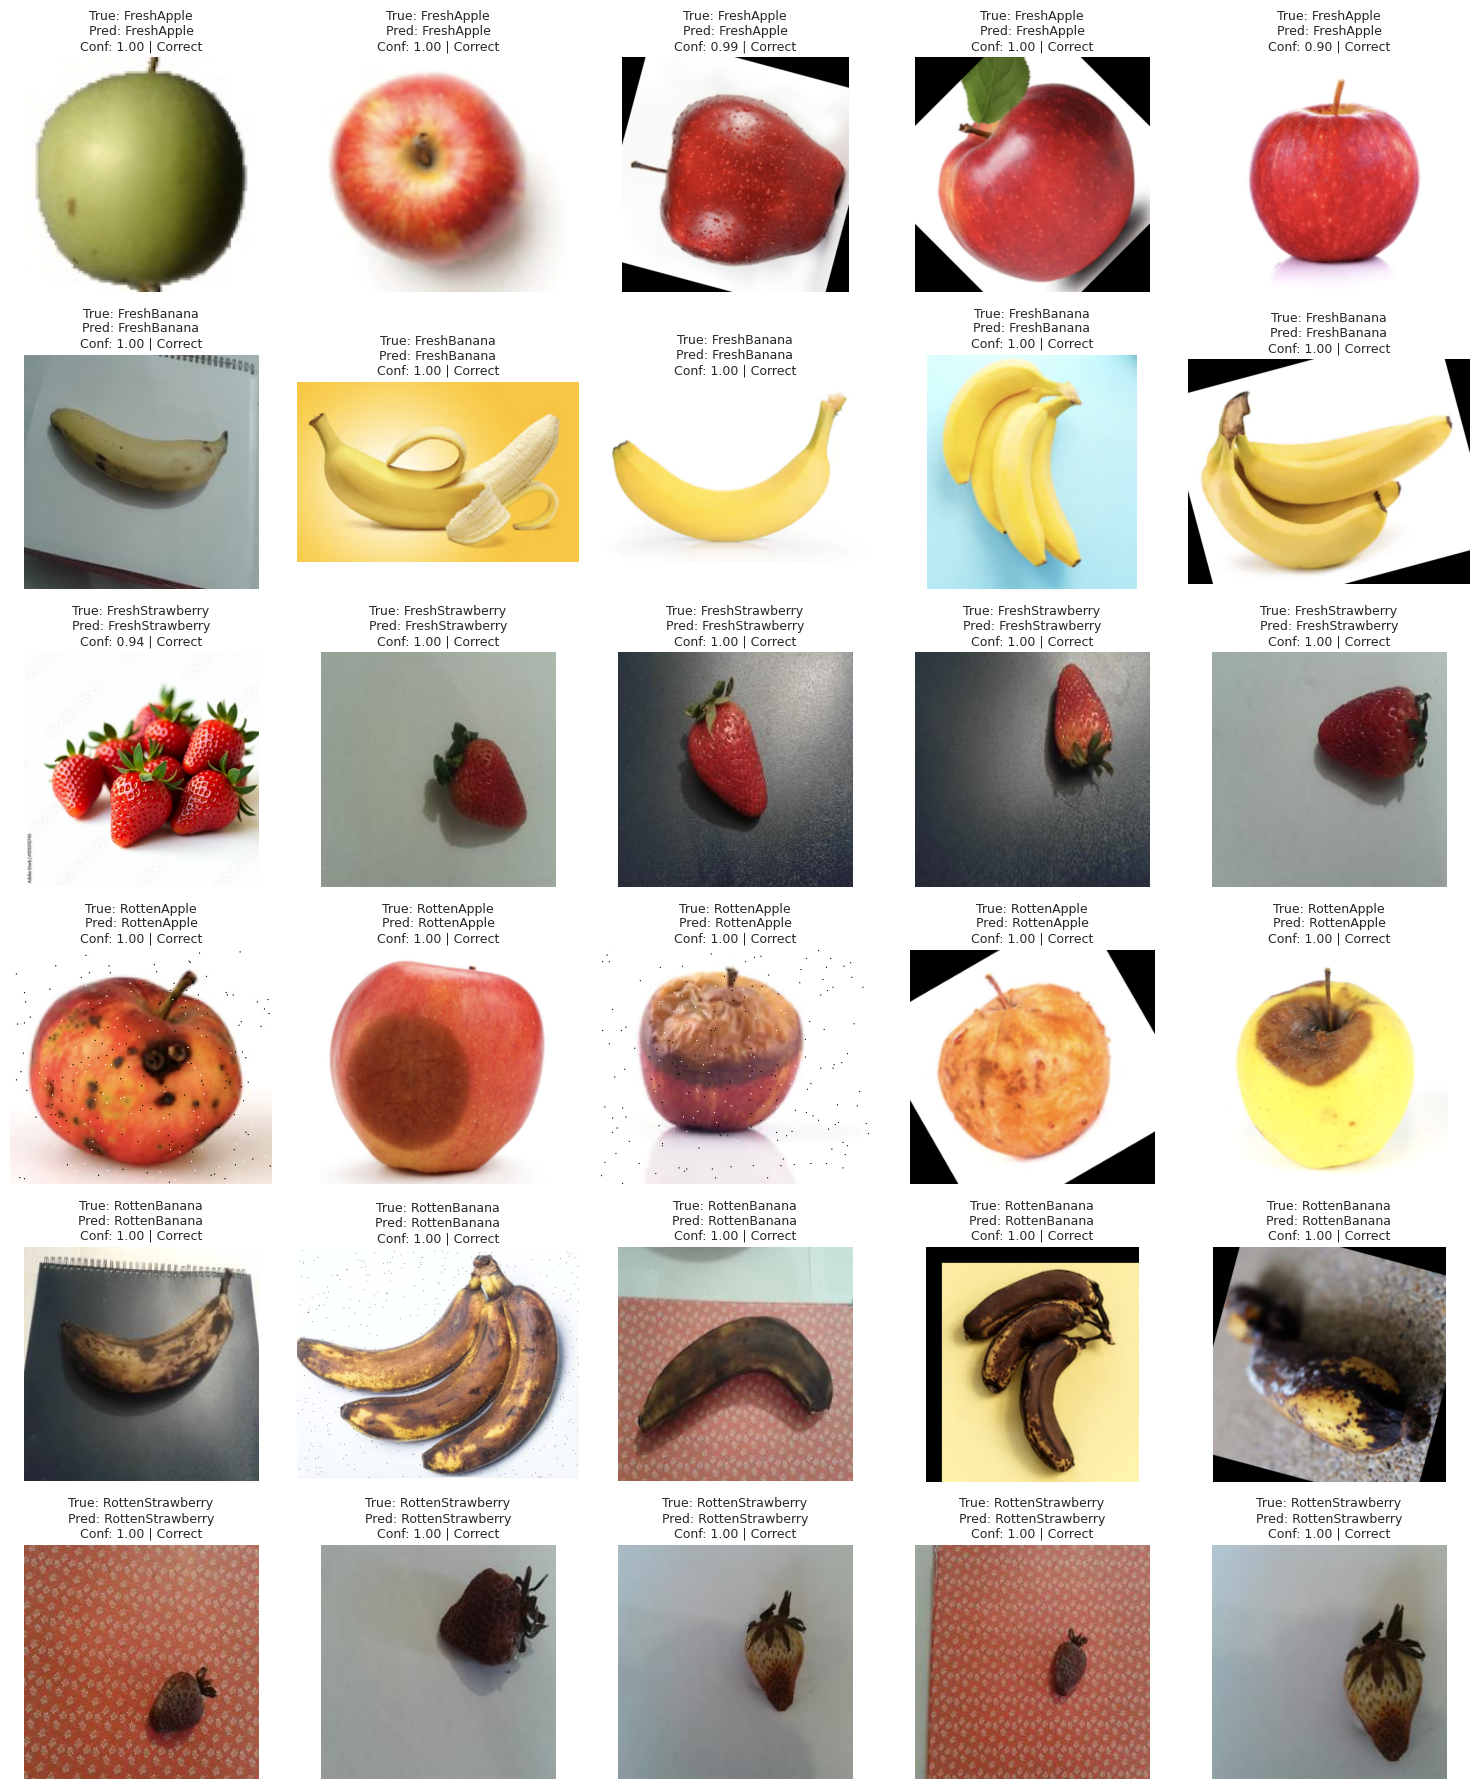

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

results_df = visualize_test_predictions_balanced(
    model=model,
    test_df=test_df,
    transform=eval_transform,
    class_names=class_names,
    device=device,
    n_per_class=5
)

In [ ]:
def visualize_wrong_test_predictions(
    model,
    test_df,
    transform,
    class_names,
    device,
    n_per_class=None,
    image_col="image_path",
    label_col="label",
    figsize_per_image=3,
    random_state=42
):
    model.eval()

    wrong_results = []

    for _, row in test_df.iterrows():
        image_path = row[image_col]
        true_label = row[label_col]

        image = Image.open(image_path).convert("RGB")
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(image_tensor)
            probs = torch.softmax(outputs, dim=1)

            pred_idx = probs.argmax(dim=1).item()
            confidence = probs[0, pred_idx].item()
            pred_label = class_names[pred_idx]

        if pred_label != true_label:
            wrong_results.append({
                "image_path": image_path,
                "true_label": true_label,
                "predicted_label": pred_label,
                "confidence": confidence
            })

    wrong_df = pd.DataFrame(wrong_results)

    if wrong_df.empty:
        print("No wrong predictions found.")
        return wrong_df

    if n_per_class is not None:
        sampled_dfs = []

        for label in class_names:
            class_wrong_df = wrong_df[wrong_df["true_label"] == label]

            if len(class_wrong_df) == 0:
                continue

            sampled_class_df = class_wrong_df.sample(
                n=min(n_per_class, len(class_wrong_df)),
                random_state=random_state
            )

            sampled_dfs.append(sampled_class_df)

        wrong_df = pd.concat(sampled_dfs).reset_index(drop=True)

    total_images = len(wrong_df)

    ncols = 3
    nrows = math.ceil(total_images / ncols)

    plt.figure(figsize=(ncols * figsize_per_image, nrows * figsize_per_image))

    for i, row in wrong_df.iterrows():
        image = Image.open(row["image_path"]).convert("RGB")

        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(image)
        plt.axis("off")

        title = (
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"Conf: {row['confidence']:.2f}"
        )

        plt.title(title, fontsize=9)

    plt.tight_layout()
    plt.show()

    return wrong_df

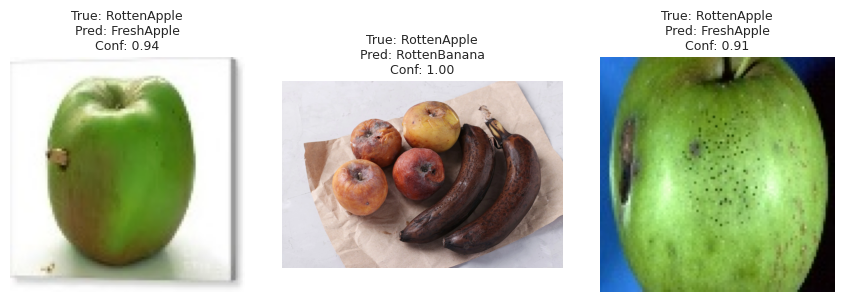

In [ ]:
wrong_df = visualize_wrong_test_predictions(
    model=model,
    test_df=test_df,
    transform=eval_transform,
    class_names=class_names,
    device=device,
    n_per_class=None
)

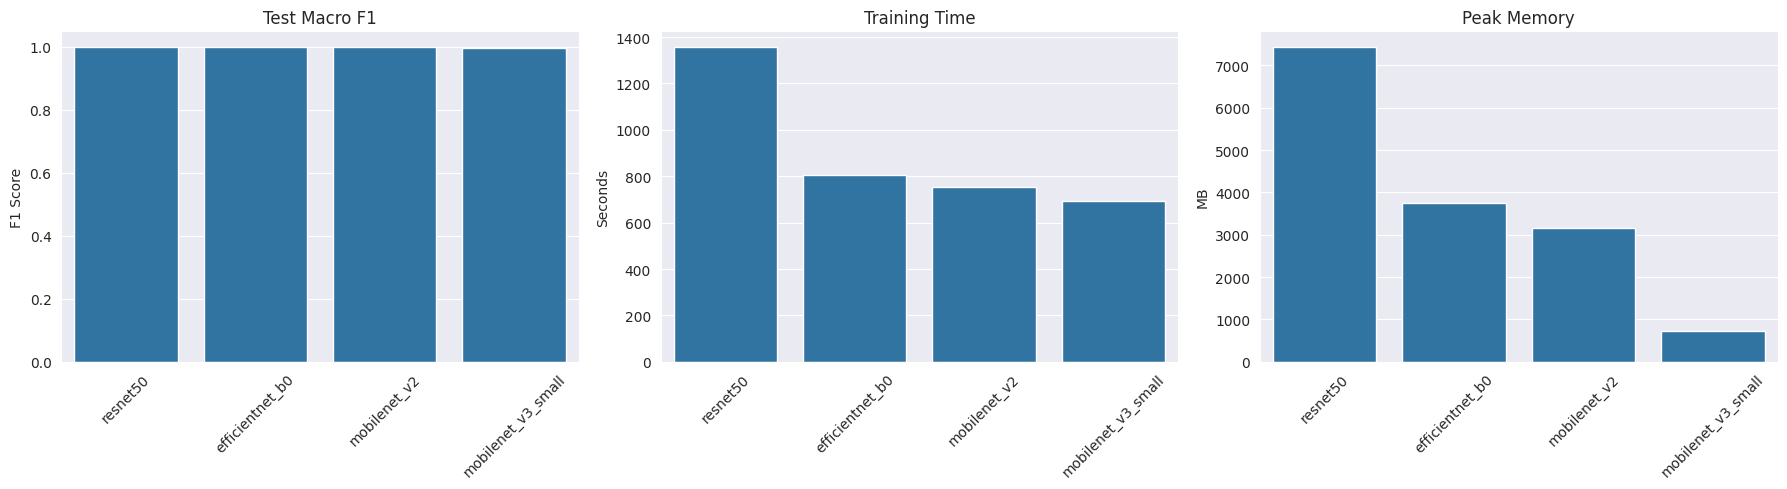

In [ ]:
comparison_plot_df = model_comparison_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=comparison_plot_df,
    x="model_name",
    y="test_f1",
    ax=axes[0]
)
axes[0].set_title("Test Macro F1")
axes[0].set_xlabel("")
axes[0].set_ylabel("F1 Score")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=comparison_plot_df,
    x="model_name",
    y="training_time_sec",
    ax=axes[1]
)
axes[1].set_title("Training Time")
axes[1].set_xlabel("")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(
    data=comparison_plot_df,
    x="model_name",
    y="peak_memory_mb",
    ax=axes[2]
)
axes[2].set_title("Peak Memory")
axes[2].set_xlabel("")
axes[2].set_ylabel("MB")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Save Model

In [ ]:
!cp -r /content/best_models drive/MyDrive/capstone/models